# 📘 Project 06 — AI-Driven Cybersecurity Threat Detection
**Team No.:** 17  
**Team Members:** Avishek Nayak; Priyanshu Das; Kasturi Adi; Hargobind Dey

**Corrected Hybrid Model:** Multi-Scale 1D-CNN + Flow Transformer + Flow-Prototype GAT

**Dataset / Source:** `madhavmalhotra/unb-cic-iot-dataset` (CICIoT2023)  
**Dataset Link:** https://www.kaggle.com/datasets/madhavmalhotra/unb-cic-iot-dataset

**Task Type:** Binary classification — BenignTraffic (0) vs Attack (1)

---
## Important correction
The original notebook mixed a *multiclass* description with a binary target (`attack_binary`) and
`BCEWithLogitsLoss`. This corrected version uses **binary attack detection consistently**.

The original "Host GAT" was also not a GAT: it embedded a hash of row numbers. CICIoT2023's
published extracted CSV features do not provide a host-ID graph suitable for a true Host GAT.
This version therefore uses a **Flow-Prototype GAT**:

1. Training flows are clustered into prototype nodes with MiniBatchKMeans.
2. Prototype nodes are connected to nearest prototype neighbors.
3. A real masked graph-attention layer propagates information over that fixed graph.
4. Each flow receives the GAT representation of its assigned prototype node.

This keeps the hybrid CNN + Transformer + GAT idea without inventing host relationships.

**How to run in Colab:** `Runtime → Change runtime type → GPU`, then `Runtime → Run all`.
Upload `kaggle.json` when prompted.


## 0. Setup — Environment, Imports, Reproducibility

In [1]:
# Colab already includes numpy/pandas/scikit-learn/matplotlib/torch.
# Install only lightweight utilities that may be missing in the active kernel.
%pip -q install kaggle tqdm tabulate


In [2]:
import os
import sys
import json
import random
import platform
import subprocess
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, roc_auc_score,
    average_precision_score, confusion_matrix, roc_curve, precision_recall_curve,
    matthews_corrcoef
)

SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()
assert torch.cuda.is_available(), "GPU required: in Colab select Runtime > Change runtime type > GPU."
DEVICE = torch.device("cuda:0")
print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device selected:", DEVICE)
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))


Python: 3.13.15
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
PyTorch: 2.11.0+cu128
CUDA available: True
Device selected: cuda:0
GPU name: Tesla T4


### CONFIG

In [3]:
CONFIG = {
    "project_no": "06",
    "project_name": "AI-Driven_Cybersecurity_Threat_Detection",
    "team_no": "17",
    "task_type": "binary_classification",
    "modality": "tabular_flow",
    "kaggle_dataset_slug": "madhavmalhotra/unb-cic-iot-dataset",
    "dataset_source": "CICIoT2023 network-flow dataset",
    "target_column": "attack_binary",
    "max_rows": 60000,

    # Download/sample multiple partitions instead of taking only one CSV.
    "n_sample_files": 16,

    # Flow Transformer
    "n_feature_groups": 8,
    "transformer_hidden": 64,

    # Flow-prototype graph
    "n_graph_nodes": 64,
    "graph_neighbors": 8,
    "gat_hidden": 32,

    # CNN / training
    "cnn_channels": 32,
    "split_ratios": {"train": 0.70, "val": 0.15, "test": 0.15},
    "random_seed": SEED,
    "batch_size": 256,
    "epochs": 20,
    "learning_rate": 1e-3,
    "early_stop_patience": 5,

    "data_raw_dir": "data/06/raw",
    "data_processed_dir": "data/06/processed",
    "figures_dir": "data/06/figures",
    "results_dir": "data/06/results",
    "reports_dir": "data/06/reports",
}

for d in [
    CONFIG["data_raw_dir"], CONFIG["data_processed_dir"], CONFIG["figures_dir"],
    CONFIG["results_dir"], CONFIG["reports_dir"]
]:
    os.makedirs(d, exist_ok=True)

CONFIG


{'project_no': '06',
 'project_name': 'AI-Driven_Cybersecurity_Threat_Detection',
 'team_no': '17',
 'task_type': 'binary_classification',
 'modality': 'tabular_flow',
 'kaggle_dataset_slug': 'madhavmalhotra/unb-cic-iot-dataset',
 'dataset_source': 'CICIoT2023 network-flow dataset',
 'target_column': 'attack_binary',
 'max_rows': 60000,
 'n_sample_files': 16,
 'n_feature_groups': 8,
 'transformer_hidden': 64,
 'n_graph_nodes': 64,
 'graph_neighbors': 8,
 'gat_hidden': 32,
 'cnn_channels': 32,
 'split_ratios': {'train': 0.7, 'val': 0.15, 'test': 0.15},
 'random_seed': 42,
 'batch_size': 256,
 'epochs': 20,
 'learning_rate': 0.001,
 'early_stop_patience': 5,
 'data_raw_dir': 'data/06/raw',
 'data_processed_dir': 'data/06/processed',
 'figures_dir': 'data/06/figures',
 'results_dir': 'data/06/results',
 'reports_dir': 'data/06/reports'}

## 1. Dataset Download

Downloads a reproducible subset of nested CICIoT2023 CSV partitions from Kaggle.


In [4]:
# Install kagglehub
!pip install -q kagglehub

import kagglehub
import os
import glob
import pandas as pd

# Download latest version of CICIoT2023 dataset
dataset_path = kagglehub.dataset_download(
    "madhavmalhotra/unb-cic-iot-dataset"
)

print("Dataset downloaded successfully.")
print("Dataset path:", dataset_path)

# Find all CSV files recursively
csv_files = glob.glob(
    os.path.join(dataset_path, "**/*.csv"),
    recursive=True
)

print(f"Total CSV files found: {len(csv_files)}")

# Display sample file paths
for file in csv_files[:5]:
    print(" -", file)

# Load first CSV file for verification
if len(csv_files) > 0:
    df = pd.read_csv(csv_files[0])
    print("\nSample CSV loaded successfully.")
    print("Shape:", df.shape)
    display(df.head())
else:
    raise FileNotFoundError("No CSV files found in the downloaded dataset.")

# Store paths for further processing
downloaded_paths = csv_files

print(f"\nReady for processing: {len(downloaded_paths)} CSV files")

  0%|          | 0.00/2.77G [00:00<?, ?B/s]

  0%|          | 1.00M/2.77G [00:00<25:11, 1.97MB/s]

  0%|          | 3.00M/2.77G [00:00<09:03, 5.47MB/s]

  0%|          | 7.00M/2.77G [00:00<03:47, 13.0MB/s]

  0%|          | 12.0M/2.77G [00:00<02:19, 21.3MB/s]

...

Extracting files...


Dataset downloaded successfully.
Dataset path: /root/.cache/kagglehub/datasets/madhavmalhotra/unb-cic-iot-dataset/versions/1
Total CSV files found: 169
 - /root/.cache/kagglehub/datasets/madhavmalhotra/unb-cic-iot-dataset/versions/1/wataiData/csv/CICIoT2023/part-00155-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
 - /root/.cache/kagglehub/datasets/madhavmalhotra/unb-cic-iot-dataset/versions/1/wataiData/csv/CICIoT2023/part-00064-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
 - /root/.cache/kagglehub/datasets/madhavmalhotra/unb-cic-iot-dataset/versions/1/wataiData/csv/CICIoT2023/part-00119-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
 - /root/.cache/kagglehub/datasets/madhavmalhotra/unb-cic-iot-dataset/versions/1/wataiData/csv/CICIoT2023/part-00006-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
 - /root/.cache/kagglehub/datasets/madhavmalhotra/unb-cic-iot-dataset/versions/1/wataiData/csv/CICIoT2023/part-00158-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv



Sample CSV loaded successfully.
Shape: (229855, 47)


,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
0,0.135516,30678.48,16.01,63.83,2102.149613,2102.149613,0.0,0.0,0.0,0.0,...,2.329577,54.00,8.301636e+07,9.5,10.607957,3.295951,45.662893,0.22,141.55,DoS-UDP_Flood
1,0.000000,54.00,6.00,64.00,65.735260,65.735260,0.0,0.0,1.0,0.0,...,0.000000,54.00,8.298538e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DoS-SYN_Flood
2,0.000000,54.00,6.00,64.00,37.173330,37.173330,0.0,0.0,0.0,0.0,...,0.000000,54.00,8.303355e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DDoS-TCP_Flood
3,9.989669,160.38,5.95,64.54,0.297307,0.297307,0.0,0.0,1.0,0.0,...,0.194146,54.44,8.298546e+07,9.5,10.396715,0.277895,1.930637,0.02,141.55,DoS-SYN_Flood
4,0.016162,65.60,6.00,99.60,24.924073,24.924073,0.0,0.0,0.0,1.0,...,1.962510,54.80,1.668466e+08,13.5,10.549914,2.778467,3.860479,1.00,244.60,Recon-HostDiscovery



Ready for processing: 169 CSV files


In [5]:
import os

# Use kagglehub downloaded path instead of old CONFIG directory
CONFIG["data_raw_dir"] = dataset_path

raw_files = []

for root, _, fnames in os.walk(CONFIG["data_raw_dir"]):
    for fn in fnames:
        raw_files.append(os.path.join(root, fn))

csv_candidates = [
    f for f in raw_files
    if f.lower().endswith(".csv")
]

print(f"{len(raw_files)} files found; {len(csv_candidates)} are CSV files.")

assert csv_candidates, (
    "No CSV files found. Check kagglehub download path."
)

# Display first CSV files with size
for f in csv_candidates[:15]:
    print(
        f,
        "-",
        round(os.path.getsize(f)/(1024*1024), 2),
        "MB"
    )

# Save CSV list for further processing
downloaded_paths = csv_candidates

print("\nCSV files ready for processing:", len(downloaded_paths))

184 files found; 169 are CSV files.
/root/.cache/kagglehub/datasets/madhavmalhotra/unb-cic-iot-dataset/versions/1/wataiData/csv/CICIoT2023/part-00155-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv - 64.55 MB
/root/.cache/kagglehub/datasets/madhavmalhotra/unb-cic-iot-dataset/versions/1/wataiData/csv/CICIoT2023/part-00064-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv - 73.91 MB
/root/.cache/kagglehub/datasets/madhavmalhotra/unb-cic-iot-dataset/versions/1/wataiData/csv/CICIoT2023/part-00119-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv - 67.39 MB
/root/.cache/kagglehub/datasets/madhavmalhotra/unb-cic-iot-dataset/versions/1/wataiData/csv/CICIoT2023/part-00006-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv - 65.66 MB
/root/.cache/kagglehub/datasets/madhavmalhotra/unb-cic-iot-dataset/versions/1/wataiData/csv/CICIoT2023/part-00158-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv - 64.76 MB
/root/.cache/kagglehub/datasets/madhavmalhotra/unb-cic-iot-dataset/versions/1/wataiData/csv/CICIoT2023/part-0

## 2. Load Raw Data

In [6]:
# Load rows from multiple downloaded partitions so the sample is not tied to one arbitrary file.
csv_candidates = sorted([f for f in raw_files if f.lower().endswith(".csv")])
assert csv_candidates, "No CSV files found."

n_files = len(csv_candidates)
rows_per_file = max(1, int(np.ceil(CONFIG["max_rows"] / n_files)))
frames = []

for i, file_path in enumerate(tqdm(csv_candidates, desc="Reading sampled partitions")):
    part = pd.read_csv(file_path, low_memory=False, nrows=rows_per_file)
    part.columns = [c.strip() for c in part.columns]
    part["_source_partition"] = os.path.basename(file_path)
    frames.append(part)

df = pd.concat(frames, ignore_index=True)

# If more than max_rows were collected, randomly cap the combined sample.
if len(df) > CONFIG["max_rows"]:
    df = df.sample(n=CONFIG["max_rows"], random_state=SEED).reset_index(drop=True)

RAW_FILE = f"{len(csv_candidates)} sampled CICIoT2023 CSV partitions"
print("Using:", RAW_FILE)
print("Combined shape:", df.shape)
display(df.head())


Reading sampled partitions:   0%|          | 0/169 [00:00<?, ?it/s]

Using: 169 sampled CICIoT2023 CSV partitions
Combined shape: (60000, 48)


,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label,_source_partition
0,0.000000,54.00,6.0,64.0,1.175664,1.175664,0.0,0.0,0.0,0.0,...,54.00,8.333086e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DDoS-PSHACK_Flood,part-00048-363d1ba3-8ab5-4f96-bc25-4d5862db7cb...
1,0.000507,1.94,46.7,64.0,39.966463,39.966463,0.0,0.0,0.0,0.0,...,573.19,8.364740e+07,9.5,33.889146,18.980839,1653.623564,0.11,141.55,Mirai-greip_flood,part-00146-363d1ba3-8ab5-4f96-bc25-4d5862db7cb...
2,0.000000,0.00,1.0,64.0,78.668164,78.668164,0.0,0.0,0.0,0.0,...,42.00,8.312465e+07,9.5,9.165151,0.000000,0.000000,0.00,141.55,DDoS-ICMP_Flood,part-00073-363d1ba3-8ab5-4f96-bc25-4d5862db7cb...
3,0.000000,54.00,6.0,64.0,6.864784,6.864784,0.0,0.0,1.0,0.0,...,54.00,8.336145e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DDoS-SynonymousIP_Flood,part-00061-363d1ba3-8ab5-4f96-bc25-4d5862db7cb...
4,5.141000,108.00,6.0,64.0,0.389029,0.389029,0.0,0.0,0.0,0.0,...,54.00,8.295582e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DoS-TCP_Flood,part-00029-363d1ba3-8ab5-4f96-bc25-4d5862db7cb...


## 3. Exploratory Data Analysis (EDA)

In [7]:
print("Shape:", df.shape)
print("Duplicate rows:", int(df.duplicated().sum()))

label_candidates = [
    c for c in df.columns
    if c.lower() in ("label", "attack", "attack_type", "class", "category")
]
if not label_candidates:
    raise KeyError(f"Could not find a label column among: {list(df.columns)}")

LABEL_COL = label_candidates[0]
print("Label column:", LABEL_COL)
print("Unique labels:", df[LABEL_COL].nunique())
print(df[LABEL_COL].value_counts().head(40))


Shape: (60000, 48)


Duplicate rows: 0
Label column: label
Unique labels: 34
label
DDoS-ICMP_Flood            9330
DDoS-UDP_Flood             6968
DDoS-TCP_Flood             5712
DDoS-SYN_Flood             5299
DDoS-PSHACK_Flood          5257
DDoS-RSTFINFlood           5167
DDoS-SynonymousIP_Flood    4583
DoS-UDP_Flood              4283
DoS-TCP_Flood              3473
DoS-SYN_Flood              2565
BenignTraffic              1361
Mirai-greeth_flood         1233
Mirai-udpplain             1174
Mirai-greip_flood           979
DDoS-ICMP_Fragmentation     625
MITM-ArpSpoofing            399
DDoS-ACK_Fragmentation      374
DDoS-UDP_Fragmentation      360
DNS_Spoofing                232
Recon-HostDiscovery         175
Recon-OSScan                118
Recon-PortScan              109
DoS-HTTP_Flood               90
VulnerabilityScan            41
DDoS-HTTP_Flood              27
DDoS-SlowLoris               23
DictionaryBruteForce         16
SqlInjection                  7
BrowserHijacking              6
XSS       

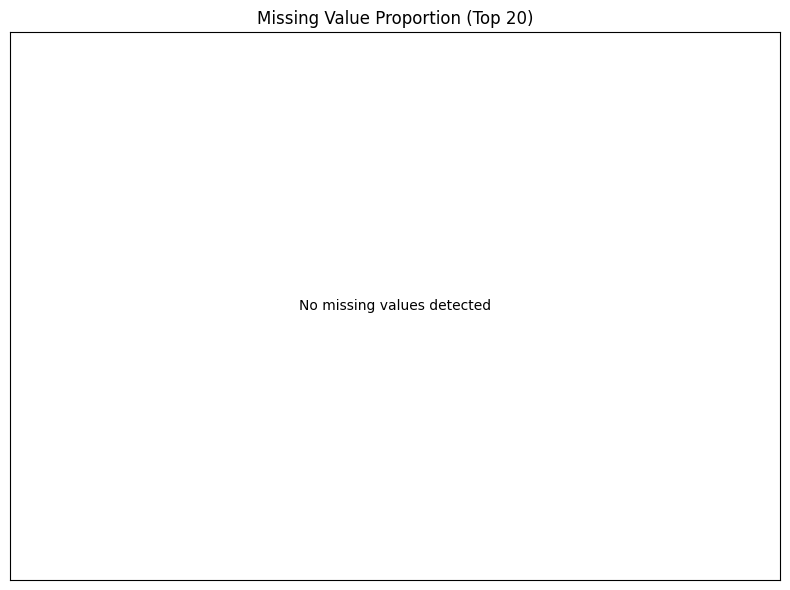

In [8]:
missing = df.isnull().mean().sort_values(ascending=False)
missing_nonzero = missing[missing > 0].head(20)

plt.figure(figsize=(8, 6))
if len(missing_nonzero):
    missing_nonzero.sort_values().plot(kind="barh")
    plt.xlabel("Missing proportion")
else:
    plt.text(
        0.5, 0.5,
        "No missing values detected",
        ha="center", va="center", transform=plt.gca().transAxes
    )
    plt.xticks([])
    plt.yticks([])

plt.title("Missing Value Proportion (Top 20)")
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["figures_dir"], "fig00_missingness.png"), dpi=300)
plt.show()


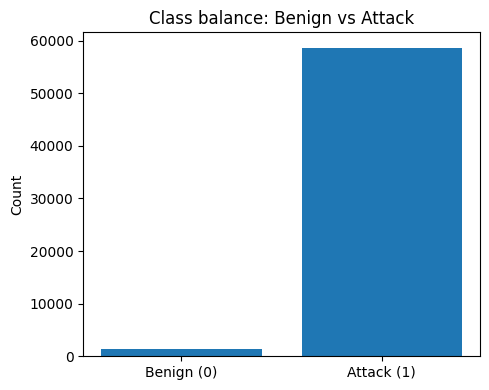

Counts:
attack_binary
0     1361
1    58639
Name: count, dtype: int64
Proportions:
attack_binary
0    0.022683
1    0.977317
Name: proportion, dtype: float64
Total rows: 60000


In [9]:
label_text = df[LABEL_COL].astype(str).str.strip().str.lower()
benign_tokens = {"benigntraffic", "benign", "normal", "background"}

df["attack_binary"] = (~label_text.isin(benign_tokens)).astype(np.int64)
target = CONFIG["target_column"]

class_counts = df[target].value_counts().sort_index()
if len(class_counts) < 2:
    raise ValueError(
        "The sampled data contains only one binary class. "
        "Increase CONFIG['n_sample_files'] or CONFIG['max_rows'] and rerun from the download/load section."
    )

counts_for_plot = class_counts.reindex([0, 1], fill_value=0)
plt.figure(figsize=(5, 4))
plt.bar(["Benign (0)", "Attack (1)"], counts_for_plot.values)
plt.ylabel("Count")
plt.title("Class balance: Benign vs Attack")
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["figures_dir"], "fig00_target_distribution.png"), dpi=300)
plt.show()

print("Counts:")
print(class_counts)
print("Proportions:")
print(df[target].value_counts(normalize=True).sort_index())

# [TARGET SANITY CHECK]
print("Total rows:", len(df))
assert df[target].nunique() > 1, f"DEGENERATE TARGET: only {df[target].nunique()} unique value(s) found - {df[target].value_counts().to_dict()}. Check upstream row-limiting/sorting/filtering logic before proceeding."
_minority_frac = df[target].value_counts(normalize=True).min()
if _minority_frac < 0.01:
    print(f"[DATA QUALITY WARNING] minority class is only {_minority_frac:.2%} of the data - results may be unstable/trivial.")
if len(df) < 100:
    print(f"[DATA QUALITY WARNING] only {len(df)} rows after filtering - too small for reliable evaluation.")


**Data quality memo**

In [10]:
data_quality_memo = f"""# Data Quality Memo - Project 06: AI-Driven Cybersecurity Threat Detection

## Dataset
- Source: {RAW_FILE}
- Rows loaded: {len(df)} (cap={CONFIG['max_rows']})
- Duplicate rows: {df.duplicated().sum()}
- Original label column: {LABEL_COL}
- Binary target: BenignTraffic=0, all attacks=1

## Missingness
{missing[missing > 0].head(10).to_string() if (missing > 0).any() else "No missing values in the top columns."}

## Leakage controls
- Original label is removed from the features.
- `_source_partition` is metadata and is removed from model features.
- Timestamp / explicit identifier-like columns are removed when present.
- Preprocessors are fit on the training split only.

## Graph correction
The original row-hash Host GAT was not a real graph model. This corrected notebook builds
a flow-prototype graph from training features with MiniBatchKMeans, connects nearest prototype
nodes, and applies masked graph attention over those nodes.

## Split limitation
This notebook uses a stratified random 70/15/15 split over the sampled flow rows. If a future
dataset version supplies stable device/host IDs, a group-aware split should be preferred.
"""

with open(os.path.join(CONFIG["reports_dir"], "data_quality_memo.md"), "w", encoding="utf-8") as f:
    f.write(data_quality_memo)

print(data_quality_memo)


# Data Quality Memo - Project 06: AI-Driven Cybersecurity Threat Detection

## Dataset
- Source: 169 sampled CICIoT2023 CSV partitions
- Rows loaded: 60000 (cap=60000)
- Duplicate rows: 0
- Original label column: label
- Binary target: BenignTraffic=0, all attacks=1

## Missingness
No missing values in the top columns.

## Leakage controls
- Original label is removed from the features.
- `_source_partition` is metadata and is removed from model features.
- Timestamp / explicit identifier-like columns are removed when present.
- Preprocessors are fit on the training split only.

## Graph correction
The original row-hash Host GAT was not a real graph model. This corrected notebook builds
a flow-prototype graph from training features with MiniBatchKMeans, connects nearest prototype
nodes, and applies masked graph attention over those nodes.

## Split limitation
This notebook uses a stratified random 70/15/15 split over the sampled flow rows. If a future
dataset version supplies stable dev

## 4. Preprocessing & Feature Engineering

In [11]:
# Remove the original label, source-partition metadata, and identifier-like fields if present.
explicit_drop = {LABEL_COL, "_source_partition"}

identifier_patterns = (
    "src_ip", "dst_ip", "source_ip", "destination_ip",
    "mac", "timestamp", "flow_id"
)

id_like_cols = [
    c for c in df.columns
    if any(p in c.lower().replace(" ", "_") for p in identifier_patterns)
]

drop_cols = [c for c in sorted(explicit_drop.union(id_like_cols)) if c in df.columns]
feature_df = df.drop(columns=drop_cols).copy()

numeric_cols = [
    c for c in feature_df.columns
    if c != target and pd.api.types.is_numeric_dtype(feature_df[c])
]
categorical_cols = [
    c for c in feature_df.columns
    if c != target and c not in numeric_cols
]

# Remove constant numeric features using only structural information.
numeric_cols = [
    c for c in numeric_cols
    if feature_df[c].nunique(dropna=True) > 1
]

feature_df = feature_df[numeric_cols + categorical_cols + [target]].copy()

print("Dropped columns:", drop_cols)
print("Numeric features:", len(numeric_cols))
print("Categorical features:", len(categorical_cols))
print("Feature frame shape:", feature_df.shape)


Dropped columns: ['_source_partition', 'label']
Numeric features: 40
Categorical features: 0
Feature frame shape: (60000, 41)


## 5. Train / Validation / Test Split

In [12]:
ratios = CONFIG["split_ratios"]

train_df, rest_df = train_test_split(
    feature_df,
    train_size=ratios["train"],
    stratify=feature_df[target],
    random_state=SEED,
)

rel_val = ratios["val"] / (ratios["val"] + ratios["test"])
val_df, test_df = train_test_split(
    rest_df,
    train_size=rel_val,
    stratify=rest_df[target],
    random_state=SEED,
)

train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

print("Train / Val / Test sizes:", len(train_df), len(val_df), len(test_df))
print("Train target distribution:\n", train_df[target].value_counts(normalize=True).sort_index())

manifest = {
    "train_rows": len(train_df),
    "val_rows": len(val_df),
    "test_rows": len(test_df),
    "seed": SEED,
    "split_ratios": ratios,
}

with open(os.path.join(CONFIG["data_processed_dir"], "split_manifest.json"), "w") as f:
    json.dump(manifest, f, indent=2)

train_df.to_csv(os.path.join(CONFIG["data_processed_dir"], "train.csv"), index=False)
val_df.to_csv(os.path.join(CONFIG["data_processed_dir"], "val.csv"), index=False)
test_df.to_csv(os.path.join(CONFIG["data_processed_dir"], "test.csv"), index=False)
manifest


Train / Val / Test sizes: 42000 9000 9000
Train target distribution:
 attack_binary
0    0.02269
1    0.97731
Name: proportion, dtype: float64


{'train_rows': 42000,
 'val_rows': 9000,
 'test_rows': 9000,
 'seed': 42,
 'split_ratios': {'train': 0.7, 'val': 0.15, 'test': 0.15}}

In [13]:
# Fit all preprocessing objects ONLY on training data.
if not numeric_cols and not categorical_cols:
    raise ValueError("No usable model features remain after preprocessing.")

def _prepare_categoricals(frame):
    out = frame.copy()
    for c in categorical_cols:
        out[c] = out[c].fillna("missing").astype(str)
    return out

train_df = _prepare_categoricals(train_df)
val_df = _prepare_categoricals(val_df)
test_df = _prepare_categoricals(test_df)

if numeric_cols:
    imputer = SimpleImputer(strategy="median")
    scaler = StandardScaler()

    train_num = imputer.fit_transform(train_df[numeric_cols])
    val_num = imputer.transform(val_df[numeric_cols])
    test_num = imputer.transform(test_df[numeric_cols])

    train_num = scaler.fit_transform(train_num)
    val_num = scaler.transform(val_num)
    test_num = scaler.transform(test_num)

    train_num_df = pd.DataFrame(train_num, columns=numeric_cols)
    val_num_df = pd.DataFrame(val_num, columns=numeric_cols)
    test_num_df = pd.DataFrame(test_num, columns=numeric_cols)
else:
    imputer = None
    scaler = None
    train_num_df = pd.DataFrame(index=np.arange(len(train_df)))
    val_num_df = pd.DataFrame(index=np.arange(len(val_df)))
    test_num_df = pd.DataFrame(index=np.arange(len(test_df)))

if categorical_cols:
    encoder = OneHotEncoder(
        handle_unknown="infrequent_if_exist",
        sparse_output=False,
        max_categories=15,
    )
    train_cat = encoder.fit_transform(train_df[categorical_cols])
    val_cat = encoder.transform(val_df[categorical_cols])
    test_cat = encoder.transform(test_df[categorical_cols])
    cat_names = encoder.get_feature_names_out(categorical_cols).tolist()

    train_cat_df = pd.DataFrame(train_cat, columns=cat_names)
    val_cat_df = pd.DataFrame(val_cat, columns=cat_names)
    test_cat_df = pd.DataFrame(test_cat, columns=cat_names)
else:
    encoder = None
    cat_names = []
    train_cat_df = pd.DataFrame(index=np.arange(len(train_df)))
    val_cat_df = pd.DataFrame(index=np.arange(len(val_df)))
    test_cat_df = pd.DataFrame(index=np.arange(len(test_df)))

train_X = pd.concat([train_num_df, train_cat_df], axis=1)
val_X = pd.concat([val_num_df, val_cat_df], axis=1)
test_X = pd.concat([test_num_df, test_cat_df], axis=1)

# Pad feature dimension so FlowTransformer can reshape into equal feature groups.
n_groups = CONFIG["n_feature_groups"]
pad = (-train_X.shape[1]) % n_groups

if pad:
    for X in (train_X, val_X, test_X):
        for i in range(pad):
            X[f"_pad{i}"] = 0.0

assert train_X.shape[1] == val_X.shape[1] == test_X.shape[1]
assert train_X.shape[1] % n_groups == 0

print("Final padded feature dim:", train_X.shape[1])
print("Transformer group size:", train_X.shape[1] // n_groups)


Final padded feature dim: 40
Transformer group size: 5


In [14]:
# Build a deterministic graph ONLY from training features.
# Nodes are KMeans flow prototypes, not row numbers or fabricated host IDs.
n_graph_nodes = min(CONFIG["n_graph_nodes"], max(2, len(train_X) // 20))
n_graph_nodes = min(n_graph_nodes, len(train_X))

kmeans = MiniBatchKMeans(
    n_clusters=n_graph_nodes,
    random_state=SEED,
    batch_size=min(2048, len(train_X)),
    n_init=10,
)
train_node_idx = kmeans.fit_predict(train_X.values)
val_node_idx = kmeans.predict(val_X.values)
test_node_idx = kmeans.predict(test_X.values)

prototype_features = kmeans.cluster_centers_.astype(np.float32)

# k-nearest-neighbor adjacency among prototype centroids.
sq = np.sum(prototype_features ** 2, axis=1, keepdims=True)
dist2 = np.maximum(sq + sq.T - 2.0 * prototype_features @ prototype_features.T, 0.0)

k = min(CONFIG["graph_neighbors"], n_graph_nodes - 1)
adjacency = np.eye(n_graph_nodes, dtype=bool)

if k > 0:
    nbrs = np.argsort(dist2, axis=1)[:, 1:k + 1]
    rows = np.arange(n_graph_nodes)[:, None]
    adjacency[rows, nbrs] = True
    adjacency = adjacency | adjacency.T

print("Graph nodes:", n_graph_nodes)
print("Average neighbors (including self):", adjacency.sum(axis=1).mean())
print("Train node assignments:", np.bincount(train_node_idx, minlength=n_graph_nodes)[:10], "...")


Graph nodes: 64
Average neighbors (including self): 13.40625
Train node assignments: [ 931  745    3  496  447   78  476 1697  578   94] ...


## 6. PyTorch Dataset & DataLoader

In [15]:
class FlowDataset(Dataset):
    def __init__(self, X_df, y_series, node_idx):
        self.X = X_df.to_numpy(dtype=np.float32, copy=True)
        self.y = y_series.to_numpy(dtype=np.float32, copy=True)
        self.node = np.asarray(node_idx, dtype=np.int64)

        if len(self.X) != len(self.y) or len(self.y) != len(self.node):
            raise ValueError("X, y, and node indices must have the same number of rows.")

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return (
            torch.from_numpy(self.X[idx]),
            torch.tensor(self.node[idx], dtype=torch.long),
            torch.tensor(self.y[idx], dtype=torch.float32),
        )

BATCH_SIZE = CONFIG["batch_size"]

train_ds = FlowDataset(train_X, train_df[target], train_node_idx)
val_ds = FlowDataset(val_X, val_df[target], val_node_idx)
test_ds = FlowDataset(test_X, test_df[target], test_node_idx)

pin_memory = torch.cuda.is_available()

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    pin_memory=pin_memory, num_workers=0
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    pin_memory=pin_memory, num_workers=0
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    pin_memory=pin_memory, num_workers=0
)

xb, xb_node, yb = next(iter(train_loader))
print("features:", xb.shape, "graph node:", xb_node.shape, "target:", yb.shape)


features: torch.Size([256, 40]) graph node: torch.Size([256]) target: torch.Size([256])


## 7. Model Definitions

In [16]:
class MultiScale1DCNN(nn.Module):
    def __init__(self, input_dim, channels=32):
        super().__init__()
        self.conv_small = nn.Conv1d(1, channels, kernel_size=3, padding=1)
        self.conv_large = nn.Conv1d(1, channels, kernel_size=7, padding=3)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.out_dim = channels * 2

    def forward(self, x):
        x = x.unsqueeze(1)  # [B, 1, F]
        small = self.pool(F.relu(self.conv_small(x))).squeeze(-1)
        large = self.pool(F.relu(self.conv_large(x))).squeeze(-1)
        return torch.cat([small, large], dim=-1)


class FlowTransformer(nn.Module):
    """Self-attention over equal-sized feature-group tokens."""
    def __init__(self, input_dim, n_groups, hidden_dim=64):
        super().__init__()
        if input_dim % n_groups != 0:
            raise ValueError("input_dim must be divisible by n_groups.")

        self.n_groups = n_groups
        self.group_size = input_dim // n_groups
        self.token_proj = nn.Linear(self.group_size, hidden_dim)

        nhead = 4
        if hidden_dim % nhead != 0:
            raise ValueError("transformer_hidden must be divisible by 4.")

        layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=nhead,
            dim_feedforward=hidden_dim * 2,
            batch_first=True,
            dropout=0.1,
            activation="gelu",
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=2)
        self.norm = nn.LayerNorm(hidden_dim)
        self.out_dim = hidden_dim

    def forward(self, x):
        B = x.shape[0]
        tokens = x.reshape(B, self.n_groups, self.group_size)
        h = self.token_proj(tokens)
        h = self.encoder(h)
        return self.norm(h.mean(dim=1))


class FlowPrototypeGAT(nn.Module):
    """Single-head GAT over a fixed graph of training-flow prototypes."""
    def __init__(self, prototype_features, adjacency, hidden_dim=32, dropout=0.1):
        super().__init__()

        proto = torch.as_tensor(prototype_features, dtype=torch.float32)
        adj = torch.as_tensor(adjacency, dtype=torch.bool)

        if proto.ndim != 2:
            raise ValueError("prototype_features must be a 2D array.")
        if adj.shape != (proto.shape[0], proto.shape[0]):
            raise ValueError("adjacency shape must match number of prototype nodes.")

        self.register_buffer("prototype_features", proto)
        self.register_buffer("adjacency", adj)

        self.node_proj = nn.Linear(proto.shape[1], hidden_dim)
        self.attn_src = nn.Linear(hidden_dim, 1, bias=False)
        self.attn_dst = nn.Linear(hidden_dim, 1, bias=False)
        self.out_proj = nn.Linear(hidden_dim, hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.out_dim = hidden_dim

    def forward(self, node_idx):
        # Node states: [N, H]
        h = self.node_proj(self.prototype_features)

        # Additive graph-attention scores e_ij = a_s(h_i) + a_t(h_j)
        src = self.attn_src(h)              # [N, 1]
        dst = self.attn_dst(h).transpose(0, 1)  # [1, N]
        e = F.leaky_relu(src + dst, negative_slope=0.2)

        # Restrict attention to graph edges.
        e = e.masked_fill(~self.adjacency, torch.finfo(e.dtype).min)
        alpha = torch.softmax(e, dim=1)
        alpha = self.dropout(alpha)

        h_graph = torch.matmul(alpha, h)
        h_graph = F.elu(self.out_proj(h_graph))

        return h_graph[node_idx]


class HybridModel(nn.Module):
    def __init__(
        self,
        input_dim,
        n_groups,
        prototype_features,
        adjacency,
        cnn_channels=32,
        transformer_hidden=64,
        gat_hidden=32,
        output_dim=1,
    ):
        super().__init__()
        self.cnn = MultiScale1DCNN(input_dim, cnn_channels)
        self.flow_transformer = FlowTransformer(input_dim, n_groups, transformer_hidden)
        self.flow_gat = FlowPrototypeGAT(prototype_features, adjacency, gat_hidden)

        fused_dim = self.cnn.out_dim + self.flow_transformer.out_dim + self.flow_gat.out_dim

        self.head = nn.Sequential(
            nn.Linear(fused_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, output_dim),
        )

    def forward(self, x, node_idx):
        h_cnn = self.cnn(x)
        h_flow = self.flow_transformer(x)
        h_graph = self.flow_gat(node_idx)
        return self.head(torch.cat([h_cnn, h_flow, h_graph], dim=-1))


### Architecture Verification

In [17]:
input_dim = xb.shape[1]
hybrid = HybridModel(input_dim=input_dim, n_groups=CONFIG['n_feature_groups'], prototype_features=prototype_features, adjacency=adjacency, cnn_channels=CONFIG['cnn_channels'], transformer_hidden=CONFIG['transformer_hidden'], gat_hidden=CONFIG['gat_hidden']).to(DEVICE)
print(hybrid)
for name, model in [('hybrid', hybrid)]:
    total = sum((p.numel() for p in model.parameters()))
    trainable = sum((p.numel() for p in model.parameters() if p.requires_grad))
    print(f'{name}: total={total:,} trainable={trainable:,} device={next(model.parameters()).device}')


HybridModel(
  (cnn): MultiScale1DCNN(
    (conv_small): Conv1d(1, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (conv_large): Conv1d(1, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (pool): AdaptiveAvgPool1d(output_size=1)
  )
  (flow_transformer): FlowTransformer(
    (token_proj): Linear(in_features=5, out_features=64, bias=True)
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-1): 2 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
          )
          (linear1): Linear(in_features=64, out_features=128, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=128, out_features=64, bias=True)
          (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=Fal

## 8. Training Loop

In [18]:
def train_model(
    model,
    train_loader,
    val_loader,
    forward_fn,
    epochs,
    lr,
    patience,
    ckpt_path,
    pos_weight=None,
):
    model.to(DEVICE)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=2, factor=0.5
    )
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    best_val_loss = float("inf")
    epochs_no_improve = 0
    history = {"train_loss": [], "val_loss": [], "lr": []}

    if len(train_loader.dataset) == 0 or len(val_loader.dataset) == 0:
        raise ValueError("Train and validation datasets must be non-empty.")

    epoch_bar = tqdm(range(epochs), desc="Training", unit="epoch")

    for epoch in epoch_bar:
        model.train()
        train_loss_sum = 0.0
        n_train = 0

        for batch in tqdm(
            train_loader,
            desc=f"Epoch {epoch + 1}/{epochs}",
            leave=False,
            unit="batch",
        ):
            optimizer.zero_grad(set_to_none=True)

            preds, targets = forward_fn(model, batch)
            loss = criterion(preds, targets)

            if not torch.isfinite(loss):
                raise FloatingPointError(f"Non-finite training loss detected: {loss.item()}")

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

            bs = targets.shape[0]
            train_loss_sum += loss.item() * bs
            n_train += bs

        train_loss = train_loss_sum / max(n_train, 1)

        model.eval()
        val_loss_sum = 0.0
        n_val = 0

        with torch.no_grad():
            for batch in val_loader:
                preds, targets = forward_fn(model, batch)
                loss = criterion(preds, targets)
                bs = targets.shape[0]
                val_loss_sum += loss.item() * bs
                n_val += bs

        val_loss = val_loss_sum / max(n_val, 1)
        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["lr"].append(optimizer.param_groups[0]["lr"])

        epoch_bar.set_postfix(
            train_loss=f"{train_loss:.4f}",
            val_loss=f"{val_loss:.4f}",
            lr=f"{optimizer.param_groups[0]['lr']:.2e}",
        )

        if val_loss < best_val_loss - 1e-6:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), ckpt_path)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                epoch_bar.write(f"Early stopping at epoch {epoch + 1}")
                break

    return history


In [19]:
def forward_fn(model, batch):
    x, node_idx, y = batch
    x = x.to(DEVICE, non_blocking=True)
    node_idx = node_idx.to(DEVICE, non_blocking=True)
    y = y.to(DEVICE, non_blocking=True)
    return (model(x, node_idx).squeeze(-1), y)
n_pos = float(train_df[target].sum())
n_neg = float(len(train_df) - n_pos)
if n_pos == 0 or n_neg == 0:
    raise ValueError('Training split must contain both benign and attack samples.')
pos_weight = torch.tensor(n_neg / n_pos, dtype=torch.float32, device=DEVICE)
print('pos_weight:', float(pos_weight.item()))
hybrid_history = train_model(hybrid, train_loader, val_loader, forward_fn, epochs=CONFIG['epochs'], lr=CONFIG['learning_rate'], patience=CONFIG['early_stop_patience'], ckpt_path=os.path.join(CONFIG['results_dir'], 'best_hybrid.pt'), pos_weight=pos_weight)


pos_weight: 0.02321728691458702


Training:   0%|          | 0/20 [00:00<?, ?epoch/s]

Epoch 1/20:   0%|          | 0/165 [00:00<?, ?batch/s]

Epoch 2/20:   0%|          | 0/165 [00:00<?, ?batch/s]

Epoch 3/20:   0%|          | 0/165 [00:00<?, ?batch/s]

...

Epoch 16/20:   0%|          | 0/165 [00:00<?, ?batch/s]

Epoch 17/20:   0%|          | 0/165 [00:00<?, ?batch/s]

Epoch 18/20:   0%|          | 0/165 [00:00<?, ?batch/s]

Epoch 19/20:   0%|          | 0/165 [00:00<?, ?batch/s]

Epoch 20/20:   0%|          | 0/165 [00:00<?, ?batch/s]

## 9. Evaluation Metrics

In [20]:
def get_predictions(model, loader, ckpt_path):
    if not os.path.exists(ckpt_path):
        raise FileNotFoundError(f"Checkpoint not found: {ckpt_path}")

    state = torch.load(ckpt_path, map_location=DEVICE, weights_only=True)
    model.load_state_dict(state)
    model.to(DEVICE)
    model.eval()

    all_probs, all_targets = [], []

    with torch.no_grad():
        for batch in loader:
            logits, targets = forward_fn(model, batch)
            probs = torch.sigmoid(logits)
            all_probs.append(probs.detach().cpu().numpy())
            all_targets.append(targets.detach().cpu().numpy())

    if not all_probs:
        raise ValueError("Prediction loader produced no batches.")

    return np.concatenate(all_probs), np.concatenate(all_targets)


def evaluate_classification(probs, targets, threshold=0.5):
    pred_labels = (probs >= threshold).astype(np.int64)

    precision, recall, f1, _ = precision_recall_fscore_support(
        targets,
        pred_labels,
        average="macro",
        zero_division=0,
    )

    return {
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(targets, pred_labels)),
        "precision_macro": float(precision),
        "recall_macro": float(recall),
        "f1_macro": float(f1),
        "mcc": float(matthews_corrcoef(targets, pred_labels)),
        "roc_auc": float(roc_auc_score(targets, probs)) if len(np.unique(targets)) > 1 else None,
        "pr_auc": float(average_precision_score(targets, probs)) if len(np.unique(targets)) > 1 else None,
    }


def choose_threshold(probs, targets):
    """Choose the validation threshold that maximizes macro-F1."""
    thresholds = np.linspace(0.05, 0.95, 181)
    scores = [
        precision_recall_fscore_support(
            targets,
            (probs >= t).astype(np.int64),
            average="macro",
            zero_division=0,
        )[2]
        for t in thresholds
    ]
    return float(thresholds[int(np.argmax(scores))])


In [21]:
results = {}
test_predictions = {}
chosen_thresholds = {}
model_specs = [('hybrid', hybrid, os.path.join(CONFIG['results_dir'], 'best_hybrid.pt'))]
for name, model, ckpt in model_specs:
    val_probs, val_targets = get_predictions(model, val_loader, ckpt)
    threshold = choose_threshold(val_probs, val_targets)
    probs, targets = get_predictions(model, test_loader, ckpt)
    results[name] = evaluate_classification(probs, targets, threshold=threshold)
    test_predictions[name] = (probs, targets)
    chosen_thresholds[name] = threshold
print('Validation-selected thresholds:', chosen_thresholds)
print(json.dumps(results, indent=2))
with open(os.path.join(CONFIG['results_dir'], 'metrics.json'), 'w') as f:
    json.dump(results, f, indent=2)


Validation-selected thresholds: {'hybrid': 0.05}
{
  "hybrid": {
    "threshold": 0.05,
    "accuracy": 0.9908888888888889,
    "precision_macro": 0.8609700684756186,
    "recall_macro": 0.9809739721263676,
    "f1_macro": 0.9118860258878378,
    "mcc": 0.8333479649064853,
    "roc_auc": 0.9970742048524731,
    "pr_auc": 0.9999328012718535
  }
}


## 10. Required Figures

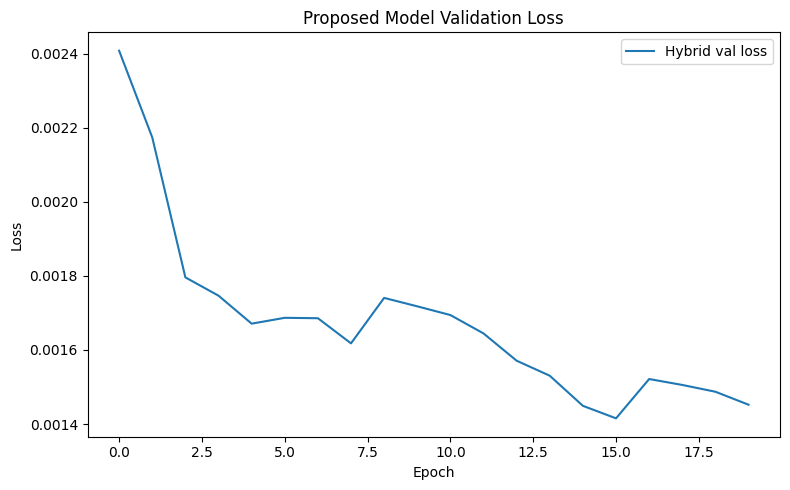

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(hybrid_history['val_loss'], label='Hybrid val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Proposed Model Validation Loss')
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['figures_dir'], 'fig01_loss_curves.png'), dpi=300)
plt.show()


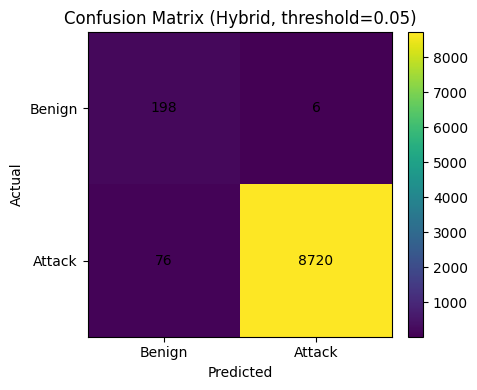

In [23]:
hybrid_probs, hybrid_targets = test_predictions["hybrid"]
hybrid_threshold = results["hybrid"]["threshold"]
hybrid_pred_labels = (hybrid_probs >= hybrid_threshold).astype(np.int64)

cm = confusion_matrix(hybrid_targets, hybrid_pred_labels, labels=[0, 1])

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm)
ax.set_xticks([0, 1], ["Benign", "Attack"])
ax.set_yticks([0, 1], ["Benign", "Attack"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix (Hybrid, threshold={hybrid_threshold:.2f})")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center")

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["figures_dir"], "fig02_confusion_or_scatter.png"), dpi=300)
plt.show()


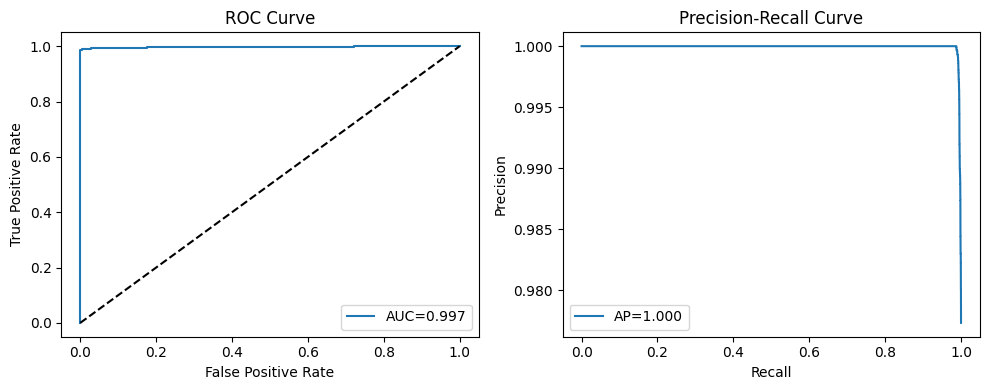

In [24]:
fpr, tpr, _ = roc_curve(hybrid_targets, hybrid_probs)
precision, recall, _ = precision_recall_curve(hybrid_targets, hybrid_probs)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(fpr, tpr, label=f"AUC={results['hybrid']['roc_auc']:.3f}")
axes[0].plot([0, 1], [0, 1], "k--")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend()

axes[1].plot(recall, precision, label=f"AP={results['hybrid']['pr_auc']:.3f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(CONFIG["figures_dir"], "fig03_roc_pr_curve.png"), dpi=300)
plt.show()


### Explainable AI

Permutation importance:   0%|          | 0/15 [00:00<?, ?it/s]

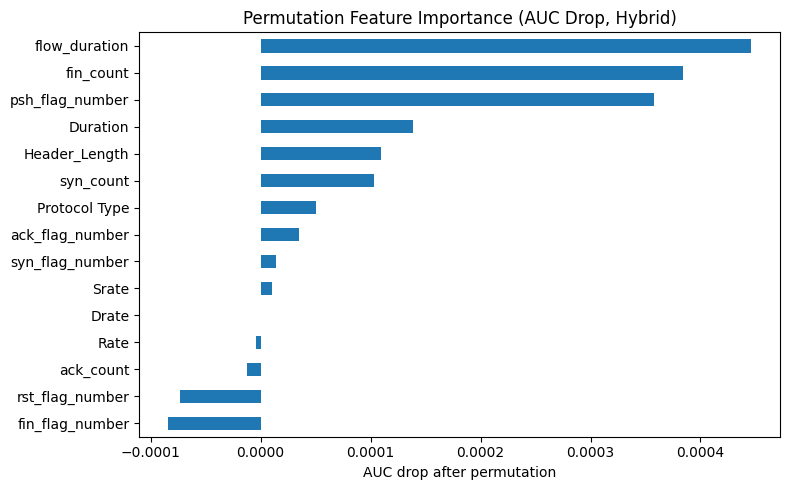

In [25]:
# Permutation importance: AUC drop on the trained hybrid model.
# We permute only flow features; prototype assignments remain the test flow's original graph node.
from sklearn.metrics import roc_auc_score as _auc

base_probs, base_targets = test_predictions["hybrid"]
base_score = _auc(base_targets, base_probs) if len(np.unique(base_targets)) > 1 else 0.5

hybrid_ckpt = os.path.join(CONFIG["results_dir"], "best_hybrid.pt")
hybrid.load_state_dict(torch.load(hybrid_ckpt, map_location=DEVICE, weights_only=True))
hybrid.to(DEVICE).eval()

rng = np.random.default_rng(SEED)
importances = {}

# Exclude artificial padding features from the explanation.
real_cols = [c for c in test_X.columns if not c.startswith("_pad")]
sample_cols = real_cols[: min(15, len(real_cols))]

for col in tqdm(sample_cols, desc="Permutation importance"):
    X_perm = test_X.copy()
    X_perm[col] = rng.permutation(X_perm[col].to_numpy())

    ds_perm = FlowDataset(X_perm, test_df[target], test_node_idx)
    loader_perm = DataLoader(ds_perm, batch_size=BATCH_SIZE, shuffle=False)

    probs_perm, targets_perm = get_predictions(hybrid, loader_perm, hybrid_ckpt)
    score_perm = _auc(targets_perm, probs_perm) if len(np.unique(targets_perm)) > 1 else 0.5
    importances[col] = base_score - score_perm

imp_series = pd.Series(importances).sort_values()

plt.figure(figsize=(8, 5))
imp_series.plot(kind="barh")
plt.title("Permutation Feature Importance (AUC Drop, Hybrid)")
plt.xlabel("AUC drop after permutation")
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["figures_dir"], "fig04_feature_importance.png"), dpi=300)
plt.show()


### Error Analysis

False negatives: 76 / 8796 attacks missed
False positives: 6 / 204 benign flows flagged


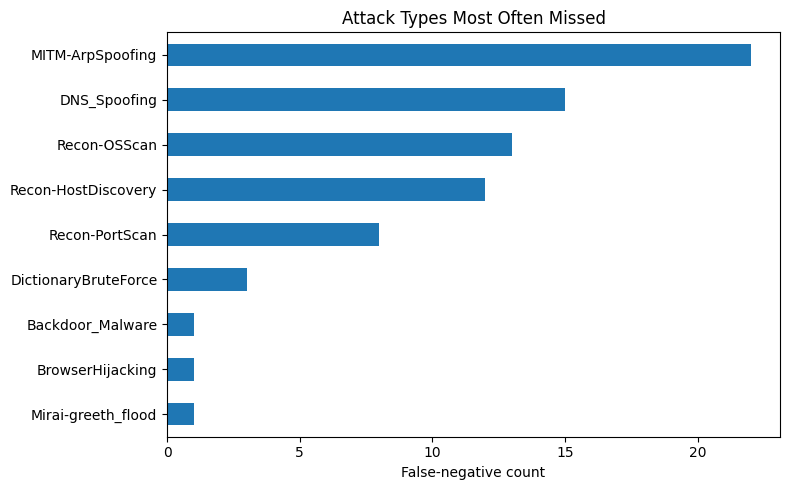

In [26]:
fn_mask = (hybrid_targets == 1) & (hybrid_pred_labels == 0)
fp_mask = (hybrid_targets == 0) & (hybrid_pred_labels == 1)

print(f"False negatives: {int(fn_mask.sum())} / {int((hybrid_targets == 1).sum())} attacks missed")
print(f"False positives: {int(fp_mask.sum())} / {int((hybrid_targets == 0).sum())} benign flows flagged")

test_labels_orig = df.loc[test_df.index, LABEL_COL].astype(str).to_numpy()
missed_types = test_labels_orig[fn_mask]
top_missed = pd.Series(missed_types).value_counts().head(10)

if len(top_missed):
    plt.figure(figsize=(8, 5))
    top_missed.sort_values().plot(kind="barh")
    plt.title("Attack Types Most Often Missed")
    plt.xlabel("False-negative count")
    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG["figures_dir"], "fig05_error_analysis.png"), dpi=300)
    plt.show()
else:
    print("No false-negative attack types to plot.")


### Computational Efficiency

In [27]:
import time
efficiency = {}
for name, model in [('hybrid', hybrid)]:
    total_params = sum((p.numel() for p in model.parameters()))
    trainable_params = sum((p.numel() for p in model.parameters() if p.requires_grad))
    model.to(DEVICE).eval()
    xb_b, xb_node_b, _ = next(iter(test_loader))
    xb_b = xb_b.to(DEVICE)
    xb_node_b = xb_node_b.to(DEVICE)
    with torch.no_grad():
        for _ in range(5):
            model(xb_b, xb_node_b)
        if DEVICE.type == 'cuda':
            torch.cuda.synchronize()
        start = time.perf_counter()
        for _ in range(30):
            model(xb_b, xb_node_b)
        if DEVICE.type == 'cuda':
            torch.cuda.synchronize()
        elapsed = (time.perf_counter() - start) / 30
    efficiency[name] = {'total_params': int(total_params), 'trainable_params': int(trainable_params), 'avg_batch_inference_time_sec': float(elapsed), 'throughput_samples_per_sec': float(xb_b.shape[0] / elapsed)}
print(json.dumps(efficiency, indent=2))
with open(os.path.join(CONFIG['results_dir'], 'efficiency.json'), 'w') as f:
    json.dump(efficiency, f, indent=2)


{
  "hybrid": {
    "total_params": 80641,
    "trainable_params": 80641,
    "avg_batch_inference_time_sec": 0.0036203003666666215,
    "throughput_samples_per_sec": 70712.36474108115
  }
}
